# Basics of OOP

In [7]:
# A class is a blueprint for crewating objects
class Animal:
    # init is going to run when we create an instance
    def __init__(self, name, sound):
        self.name=name
        self.sound=sound
        # instance attribute as seen above

        # instance method
    def speak(self):
        return f"{self.name} says {self.sound}";
    def __repr__(self):
        return f"Animal(name={self.name})"



In [9]:
# Create instances
dog=Animal("Dog", "Woof")
cat=Animal("Cat", "Meow")
print(cat.speak())   # "Dog says woof"

Cat says Meow


In [12]:
class Dog(Animal):
    def __init__(self, name, breed):
        super().__init__(name, "woof") # Call parent'8.2 The nn.Module Pattern — The Core of PyTorch
 __init__
        self.breed=breed
    def fetch(self):
        return f"{self.name} fetches the ball!"
    # overrides the parent method
    def speak(self):
        return f"{self.name} barks loudly: WOOF WOOF!"
rex=Dog("Rex", "German shepherd")
print(rex.speak())
print(rex.fetch())

Rex barks loudly: WOOF WOOF!
Rex fetches the ball!


## 8.2 The nn.Module Pattern — The Core of PyTorch
Every neural network in PyTorch inherits from torch.nn.Module . This is the most important class in PyTorch.
When you inherit from nn.Module , your class gets superpowers:
Automatically tracks all nn.Parameter and sub-modules

In [19]:
import torch
import torch.nn as nn



class SimpleLinearModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        # Always call super.__init__() first - this initializes nn.Module
        super().__init__()
        # Define layers as attributes
        # nn.Module automatically register these as sub modules
        self.layer1=nn.Linear(input_size, hidden_size)
        self.activation=nn.ReLU()
        self.layer2=nn.Linear(hidden_size, output_size)
    def forward(self, x):
        # Define how data flows through the network
        # This is called when you do Model(x)
        x=self.layer1(x)  # Linear Transformatiom
        x=self.activation(x) #  Non-linearity
        x=self.layer2(x)   # Output Layer
        return x



# DIFEREMTIATE BETWEEN TRAINABLE PARAMS AND PARAMS
        

In [20]:
# Create a model instance
model=SimpleLinearModel(input_size=10, hidden_size=64, output_size=3)

# Explore the model
print(model)
print(model.layer1)
        


SimpleLinearModel(
  (layer1): Linear(in_features=10, out_features=64, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=64, out_features=3, bias=True)
)
Linear(in_features=10, out_features=64, bias=True)


# training a simpel neural network

using the iris dataset on iris flowers, neural nets to classify iris flowers

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [21]:
# Create a Model calss that inherits nn.Module
class Model(nn.Module):
    # input layer (4 features of the flower)--> Hidden layer1 (number of neurons)
    # -->H2(some number of neurons)
    # -->output (tell us one of our three  classes of iris flowers)
    def __init__(self, in_features=4,h1=8, h2=9, out_features=3):
        super().__init__()  #instantiate our nn.module
        # setup our layers
        # fc=fully connected
        self.fc1=nn.Linear(in_features, h1)
        self.fc2=nn.Linear(h1, h2)
        self.out=nn.Linear(h2, out_features)

        # Create a function that moves everything forward:
    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.out(x)

        return x
    

In [23]:
# Create a random seed to reproduce random values
torch.manual_seed(42)
# create an instance of our model
model=Model()
model

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

In [5]:
model.parameters

<bound method Module.parameters of Model(
  (fci): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

# Loading Real data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("iris.csv")
df.head(5)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
all_cols=[cols for cols in df.columns]

all_cols


['Id',
 'SepalLengthCm',
 'SepalWidthCm',
 'PetalLengthCm',
 'PetalWidthCm',
 'Species']

In [17]:
# df['column_name'].unique() to get an array of all unique category names.

In [4]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [5]:
# changing our species colums to numbers
# df["Species"]=df["Species"].replace("Iris-setosa", 0.0)
# df["Species"]=df["Species"].replace("Iris-versicolor", 1.0)
# df["Species"]=df["Species"].replace("Iris-virginica", 2.0)


# ___________________________or____________________________________________

species_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}
df["Species"] = df["Species"].map(species_mapping)

# sanity check: this should print False, meaning nothing failed to map
print(df["Species"].isna().any())
print(df["Species"].dtype)

False
int64


In [6]:
df.head(4)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0


In [7]:
X = df.drop(["Id", "Species"], axis=1).values
y = df["Species"].values
X.shape

(150, 4)

In [22]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [42]:
X.dtypes

AttributeError: 'numpy.ndarray' object has no attribute 'dtypes'

In [55]:
# Convert data to numpy array
X=X.values
y=y.values


AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [46]:
y

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2,random_state=42)
X_train

X_train.shape

(120, 4)

In [11]:
import torch

In [12]:
# Convert numpy arrays to tensors
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)
# long tensors are 62 bits integers 
# y_test
# X_train

In [13]:
print(df["Species"].unique())
print(df["Species"].dtype)

[0 1 2]
int64


In [24]:
# sET THE CRITERION OF OUR MODEL TO MEASURE THE ERRRO
criterion=nn.CrossEntropyLoss()

# choose an optimizer (Adam optimizer) and and a learning  rate
optimizer=torch.optim.Adam(model.parameters(), lr=0.01)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

In [47]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [27]:
# TrAIN OUR MODEL [how many epochs do we want ... one run through our neural network in a time]
epochs=1000
losses=[]
for i in range(epochs):
    # go forward and get a prediction
    y_pred=model.forward(X_train)  #get predicted results
    # criteriom
    loss=criterion(y_pred, y_train) # predicted values vs the y_train
    losses.append(loss.item())
    if i%10==0:
        print(f"Epoch: {i}  and loss: {loss}")
# dO SOME BACK PROPAGATION take the error rate of forward propagation and feed it back
# through the network to fine tune the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

Epoch: 0  and loss: 0.06436478346586227
Epoch: 10  and loss: 0.06153516098856926
Epoch: 20  and loss: 0.05974332615733147
Epoch: 30  and loss: 0.058478038758039474
Epoch: 40  and loss: 0.057511623948812485
Epoch: 50  and loss: 0.05673066899180412
Epoch: 60  and loss: 0.05607355758547783
Epoch: 70  and loss: 0.05550341680645943
Epoch: 80  and loss: 0.05499691143631935
Epoch: 90  and loss: 0.05453849211335182
Epoch: 100  and loss: 0.0541173554956913
Epoch: 110  and loss: 0.05372582748532295
Epoch: 120  and loss: 0.053406793624162674
Epoch: 130  and loss: 0.05310038849711418
Epoch: 140  and loss: 0.05278899520635605
Epoch: 150  and loss: 0.05246787145733833
Epoch: 160  and loss: 0.05220171436667442
Epoch: 170  and loss: 0.051948223263025284
Epoch: 180  and loss: 0.05169505998492241
Epoch: 190  and loss: 0.0514550544321537
Epoch: 200  and loss: 0.05122348293662071
Epoch: 210  and loss: 0.05100003257393837
Epoch: 220  and loss: 0.05078364908695221
Epoch: 230  and loss: 0.05057418346405029
E

# Visualization

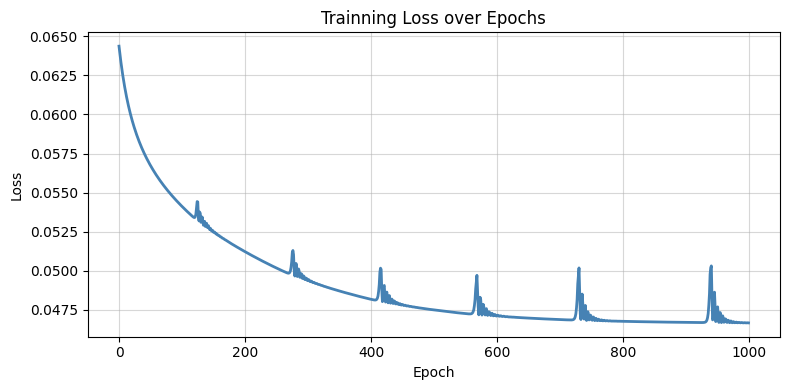

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(epochs), losses, color="steelblue", linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Trainning Loss over Epochs')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# EVALUATION

In [38]:
with torch.no_grad():
    y_eval=model(X_test)
    preds=torch.argmax(y_eval, dim=1)
    print(f"Predictions are: {preds}")
    correct=(preds==y_test).sum().item()
    print(f"Correct prediction are: {correct}")
    acc=correct/len(y_test)
    print(f"\nTest accutacy: {acc:.2%}")

Predictions are: tensor([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2,
        2, 2, 2, 2, 0, 0])
Correct prediction are: 30

Test accutacy: 100.00%


# EVALUATION METHOD 2: 

In [41]:
with torch.no_grad():
    for i, data in enumerate(y_test):
        print(data)
        # y_val=model.forward(data)
        # # will tell us what type of flower class our network things  it is
        # print(f"{i+1} {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}")

tensor(1)
tensor(0)
tensor(2)
tensor(1)
tensor(1)
tensor(0)
tensor(1)
tensor(2)
tensor(1)
tensor(1)
tensor(2)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(1)
tensor(2)
tensor(1)
tensor(1)
tensor(2)
tensor(0)
tensor(2)
tensor(0)
tensor(2)
tensor(2)
tensor(2)
tensor(2)
tensor(2)
tensor(0)
tensor(0)
